In [48]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('dvdrental1.csv')
data2 = pd.read_csv('dvdrental2.csv')
df = pd.DataFrame(data)
df2 = pd.DataFrame(data2)

df['payment_date'] = pd.to_datetime(df['payment_date'])
df['rental_date'] = pd.to_datetime(df['rental_date'])
df2['rental_date'] = pd.to_datetime(df2['rental_date'])



## Q1 : What is the total revenue generated? 

In [11]:
total = df['amount'].sum().round()

print(total)

61312.0


## Q2 : Revenue contribution (%) by category .

Sports: 7.98%
Sci-Fi: 7.07%
Animation: 6.92%
Drama: 6.72%
Comedy: 6.53%
New: 6.47%
Action: 6.45%
Foreign: 6.42%
Games: 6.40%
Family: 6.25%
Documentary: 6.12%
Horror: 5.55%
Classics: 5.47%
Children: 5.40%
Travel: 5.26%
Music: 5.01%


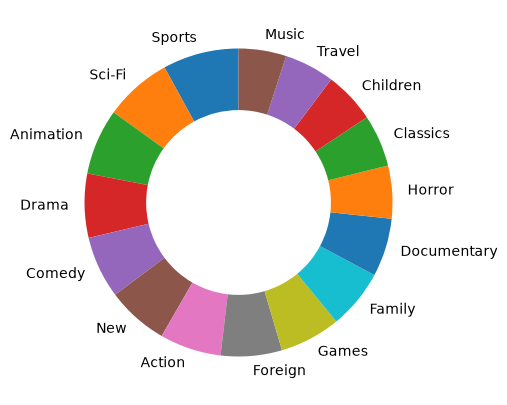

In [68]:
contribution = df.groupby('category')['amount'].sum().sort_values(ascending=False)
contribution = (contribution/contribution.sum())*100

for category, value in contribution.items():
    print(f"{category}: {value:.2f}%")

plt.figure(figsize=(10,5))
plt.pie(
    contribution.values,
    labels=contribution.index,
    startangle=90,
    wedgeprops={'width': 0.4}   # يجعلها Donut
)

Sports films have the highest revenue contribution.

## Top 3 countries by revenue.

India  9.84%
China  8.56%
United States  6.01%


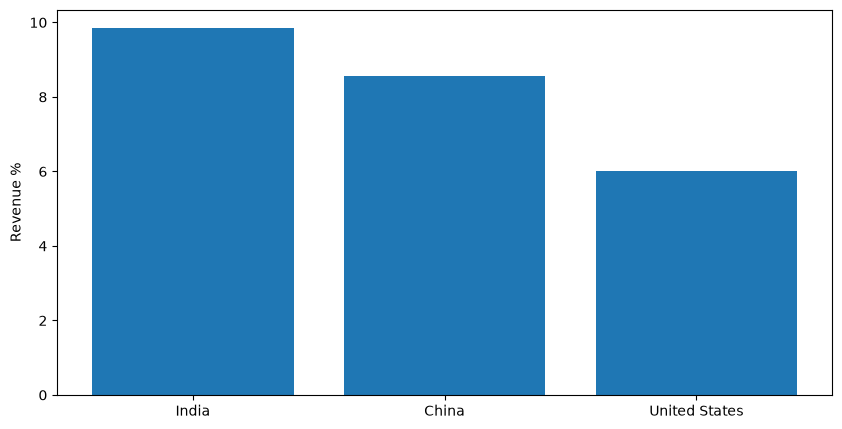

In [36]:
totalRevenu = df.groupby('country')['amount'].sum().sort_values(ascending=False)
totalRevenu = (totalRevenu/totalRevenu.sum())*100

for category,value in totalRevenu.head(3).items():
    print(f"{category}  {value:.2f}%")

plt.figure(figsize=(10,5))

plt.bar(totalRevenu.head(3).index,totalRevenu.head(3).values)
plt.ylabel('Revenue %')
plt.show()


India, China, and the USA are the top 3 countries by revenue, contributing a combined 24% of total revenue.

In [14]:
## Q3 : Which films generated most revenu?

In [15]:
topFilms = df.groupby('film_title')['amount'].sum().sort_values(ascending=False).head(3)

print(topFilms)

film_title
Telegraph Voyage    215.75
Zorro Ark           199.72
Wife Turn           198.73
Name: amount, dtype: float64


The top 3 revenue-generating films are :

1- Telegraph Voyage
2- Zorro Ark 
3- Wife Turn

## Q4 : Average customer lifetime value CLV.

In [16]:
clv = df.groupby('customer_name')['amount'].sum()

print(clv.mean().round(2))

102.36


Each customer generate in average 102$ in lifetime revenue.

## Customers with the highest rental frequency.

In [17]:
topCustomers = df2.groupby('customer_name')['rental_id'].count().sort_values(ascending=False).head(3)

print(topCustomers)

customer_name
Eleanor Hunt    46
Karl Seal       45
Marcia Dean     42
Name: rental_id, dtype: int64


## Rental trend over time (Growth/Decline).

rental_date
2005-05    1156
2005-06    2311
2005-07    6709
2005-08    5686
2006-02     182
Freq: M, dtype: int64


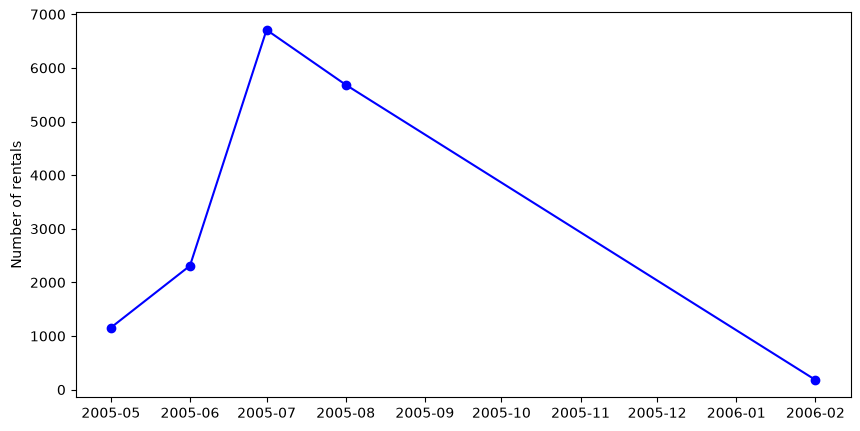

In [60]:
rental_trend = (
    df2.groupby(df2['rental_date'].dt.to_period('M'))
       .size()
)

print(rental_trend)

plt.figure(figsize=(10,5))
plt.plot(rental_trend.index.to_timestamp(),rental_trend.values,marker='o',color='blue')
plt.ylabel('Number of rentals')

plt.show()


